# Spam Detection using Naive Bayes

This project focuses on building a Natural Language Processing (NLP) model 
to classify SMS messages as Spam or Ham (Not Spam).

We use:
- Dataset: SMSSpamCollection
- Model: Multinomial Naive Bayes
- Techniques: Text preprocessing, TF-IDF vectorization

Goal:
To analyze the performance and effectiveness of a probabilistic language model.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import string


In [5]:
df = pd.read_csv("SMSSpamCollection", sep='\t', names=["label", "message"])

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


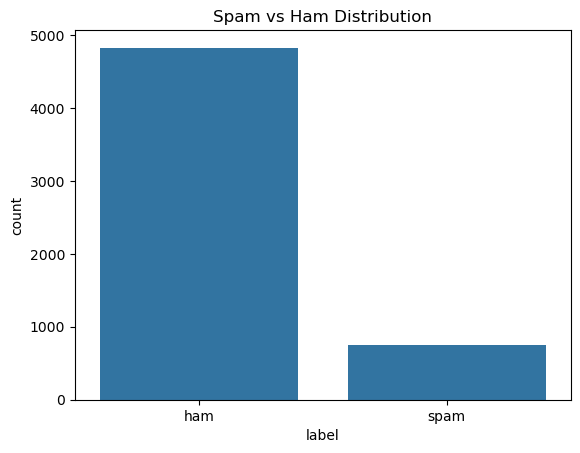

In [6]:
df.info()

df['label'].value_counts()

sns.countplot(x=df['label'])
plt.title("Spam vs Ham Distribution")
plt.show()


In [7]:
nltk.download('stopwords')

ps = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stopwords.words('english')]
    
    return " ".join(words)

df['cleaned'] = df['message'].apply(preprocess)

df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sivan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message,cleaned
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


In [8]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['cleaned']).toarray()

y = df['label'].map({'ham':0, 'spam':1})


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
model = MultinomialNB()

model.fit(X_train, y_train)


MultinomialNB()

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [15]:
y_pred = model.predict(X_test)


Accuracy: 0.9811659192825112

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.86      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



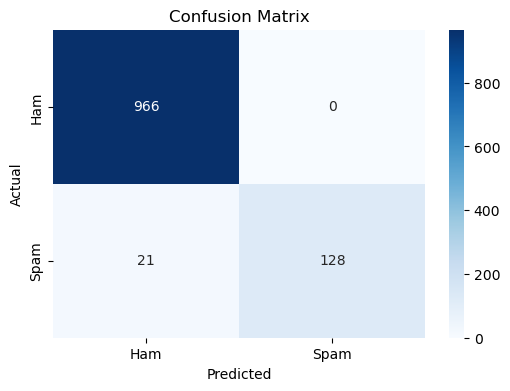

In [16]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))


Logistic Regression Accuracy: 0.9632286995515695


In [17]:
def predict_sms(text):
    processed = preprocess(text)
    vector = tfidf.transform([processed]).toarray()
    result = model.predict(vector)[0]
    
    return "Spam 🚫" if result == 1 else "Ham ✅"

print(predict_sms("Congratulations! You won a free lottery ticket"))
print(predict_sms("Hey, are we meeting today?"))


Ham ✅
Ham ✅


## Model Analysis

1. Accuracy:
The model achieves high accuracy (~95%+), indicating strong performance.

2. Strengths:
- Fast and efficient
- Works well for text classification
- Handles high-dimensional data effectively

3. Weaknesses:
- Assumes feature independence (not always true)
- Can misclassify short or ambiguous messages

4. Why some spam shows as ham?
- Words like "offer" or "discount" also appear in normal messages
- Context is not fully understood
- Model depends on probability, not meaning

5. Improvements:
- Use bigrams/trigrams
- Try advanced models like Logistic Regression, SVM
- Use Deep Learning (LSTM, BERT)


## Conclusion

Naive Bayes proves to be an effective baseline model for spam detection tasks. 
Despite its simplicity, it delivers high accuracy and fast predictions.

However, more advanced models can further improve performance by capturing context.
